In [ ]:
import numpy as np
import matplotlib.pyplot as plt

statistics mean +/- std: 4.997911 +/- 2.991907


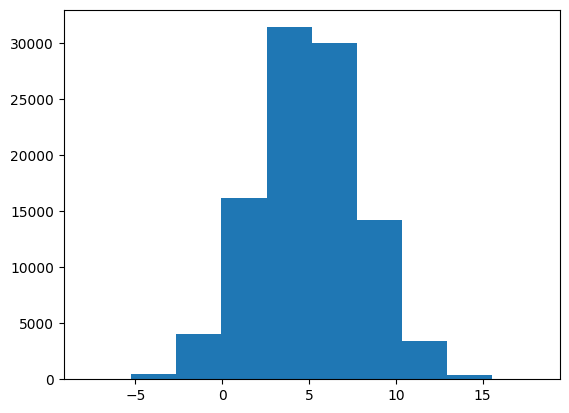

In [ ]:
location = 5
scale = 3
size = 100000
values = np.random.normal(location, scale, size)

print('statistics mean +/- std: {0:4f} +/- {1:4f}'.format(np.mean(values), np.std(values)))

plt.hist(values)
plt.show()

nbatch = size/2000
batches = np.arange(0, size+2000, 2000)

0 iteration statistics mean +/- std: 3.609779 +/-  nan
2000 iteration statistics mean +/- std: 5.055514 +/- 2.909860
4000 iteration statistics mean +/- std: 5.055085 +/- 2.953715
6000 iteration statistics mean +/- std: 5.051214 +/- 2.959705
8000 iteration statistics mean +/- std: 5.039410 +/- 2.968909
10000 iteration statistics mean +/- std: 5.041109 +/- 2.967816
12000 iteration statistics mean +/- std: 5.040630 +/- 2.966191
14000 iteration statistics mean +/- std: 5.016471 +/- 2.978165
16000 iteration statistics mean +/- std: 5.014551 +/- 2.974925
18000 iteration statistics mean +/- std: 5.000695 +/- 2.985321
20000 iteration statistics mean +/- std: 4.993716 +/- 2.982715
22000 iteration statistics mean +/- std: 5.011264 +/- 2.982747
24000 iteration statistics mean +/- std: 4.999490 +/- 2.985844
26000 iteration statistics mean +/- std: 4.986877 +/- 2.988978
28000 iteration statistics mean +/- std: 4.992917 +/- 2.985332
30000 iteration statistics mean +/- std: 4.986833 +/- 2.985146
3200

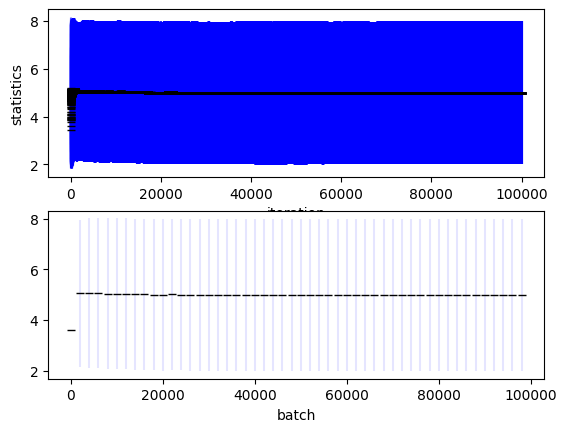

0 iteration statistics mean +/- std: 3.609779 +/-  nan
2000 iteration statistics mean +/- std: 5.056237 +/- 2.910407
4000 iteration statistics mean +/- std: 5.054656 +/- 2.996949
6000 iteration statistics mean +/- std: 5.043469 +/- 2.971637
8000 iteration statistics mean +/- std: 5.003992 +/- 2.996078
10000 iteration statistics mean +/- std: 5.047908 +/- 2.963429
12000 iteration statistics mean +/- std: 5.038235 +/- 2.958049
14000 iteration statistics mean +/- std: 4.871507 +/- 3.045003
16000 iteration statistics mean +/- std: 5.001108 +/- 2.952111
18000 iteration statistics mean +/- std: 4.889837 +/- 3.064971
20000 iteration statistics mean +/- std: 4.930901 +/- 2.958412
22000 iteration statistics mean +/- std: 5.186750 +/- 2.977393
24000 iteration statistics mean +/- std: 4.869976 +/- 3.016668
26000 iteration statistics mean +/- std: 4.835509 +/- 3.022225
28000 iteration statistics mean +/- std: 5.071450 +/- 2.936387
30000 iteration statistics mean +/- std: 4.901649 +/- 2.981248
3200

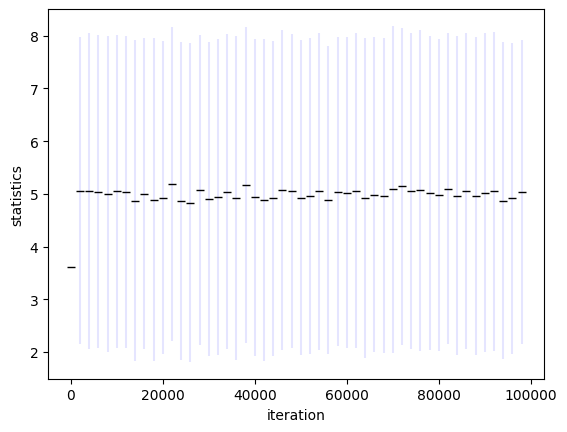

In [18]:
def welford_stat_update(count, mean, M2, newdata):
    """Perform one step of Welford's online algorithm for computing mean and variance.

    Args:
        count: Current sample count.
        mean: Current running mean.
        M2: Current sum of squared differences from the mean.
        newdata: New data point to incorporate.

    Returns:
        Tuple of (count, mean, M2) updated with the new data point.
    """
    count += 1
    delta = newdata - mean
    mean += delta / count
    delta2 = newdata - mean
    M2 += delta * delta2

    return count, mean, M2


def welford_stat_finalize(count, mean, M2):
    """Finalize Welford's algorithm to compute the mean and variance.

    Args:
        count: Total sample count.
        mean: Running mean from welford_stat_update.
        M2: Sum of squared differences from welford_stat_update.

    Returns:
        Tuple of (mean, variance). Returns (mean, NaN) if count < 2.
    """
    if count < 2:
        return mean, np.nan
    else:
        variance = np.sqrt(M2 / count)
        return mean, variance

fig, axs = plt.subplots(2,1)

count = 0
mean = 0
M2 = 0
for v, value in enumerate(values):
  count, mean, M2 = welford_stat_update(count, mean, M2, newdata=value)
  mean, variance = welford_stat_finalize(count, mean, M2)
  axs[0].errorbar(v, mean, yerr=variance, marker='_',  color='k', ecolor=(0,0,1,0.1))
  if (v%2000) == 0:
    print('{0} iteration statistics mean +/- std: {1:4f} +/- {2:4f}'.format(v, mean, variance))
    axs[1].errorbar(v, mean, yerr=variance, marker='_',  color='k', ecolor=(0,0,1,0.1))
axs[0].set_ylabel('statistics')
axs[0].set_xlabel('iteration')
axs[1].set_xlabel('batch')
plt.show()

count = 0
mean = 0
M2 = 0
for v, value in enumerate(values):
  count, mean, M2 = welford_stat_update(count, mean, M2, newdata=value)
  mean, variance = welford_stat_finalize(count, mean, M2)
  if (v%2000) == 0:
    print('{0} iteration statistics mean +/- std: {1:4f} +/- {2:4f}'.format(v, mean, variance))
    plt.errorbar(v, mean, yerr=variance, marker='_',  color='k', ecolor=(0,0,1,0.1))
    #reset at each batch
    count = 0
    mean = 0
    M2 = 0
plt.ylabel('statistics')
plt.xlabel('iteration')
plt.show()